### QICK Standard ZCU111 Firmware + FFT/Spectrum Analysis

This firmware is a standard ZCU111 firmware (with less SGv6 though to make room for the BREAD Small logic) + BREAD Small chain. 
The BREAD small chain is a reduced FFT version (16k in place of 32k points) of the BREAD Real project.

BREAD Small part: this part has one input ADC and one output DAC. ADC is connected to Tile 224 Channel 0. DAC is connected to Tile 229 Channel 2.

There's an option to connect ADC_224_0 to a Readout path to capture data with the tProcessor.

See examples to extract data from the different points.

<!-- ![alt text](images/std_111_bread_small.png "Block Diagram") -->
<!-- ![alt text](images/qick_tprocv2_111_fft_spectrum_diagram.png "Block Diagram") -->
<img src="images/qick_diagrams-QICK_TPROCV2_111_FFT_SPECTRUM.drawio.png" alt="Placeholder" width="1200" height="1000">


# FFT spectrum firmware data analysis
This part of the notebook analyzes the data obtained at the **ACCUMULATOR_1** core in the diagram above.

System description:

- ADC resolution: 12 bits (signed)
- Full-scale (FS) amplitude = 2^(11) = 2048
- Sampling rate Fs = 32 MHz
- FFT size N = 65536
- FFT has NO internal scaling
- FFT IP outputs averaged power per bin:

\begin{equation}
    P[k] = average( |X[k]|^2 )
  \end{equation}

- Signal is complex (IQ)
- Tone has been digitally mixed to DC

# Notebook Section 2 — Mathematical Background

## (1) What does the FFT compute?

Since the FFT is unscaled:

$$
\begin{equation}
X[k] = \sum_{n=0}^{N-1} x[n] e^{-j2\pi kn/N}
\end{equation}
$$

For a coherent complex tone (tone whose frequency is exactly aligned with a bin of the FFT):

$$
\begin{equation}
|X[k_0]| = N \cdot A
\end{equation}
$$

Where:

* $( A )$ = actual tone amplitude in ADC LSB units.

Therefore:

$$
\begin{equation}
A = \frac{|X[k_0]|}{N}
\end{equation}
$$

---

## (2) What does the IP give us?
The IP (FFT + Accumulator) gives:

$$
\begin{equation}
P[k] = |X[k]|^2
\end{equation}
$$

So:

$$
\begin{equation}
|X[k]| = \sqrt{P[k]}
\end{equation}
$$

Therefore:

$$
\begin{equation}
A = \frac{\sqrt{P[k]}}{N}
\end{equation}
$$

---

## (3) Convert to dBFS

Full-scale amplitude:

$$
\begin{equation}
FS = 2^{13} = 8192
\end{equation}
$$

Normalized amplitude:

$$
\begin{equation}
A_{FS} = \frac{A}{FS}
\end{equation}
$$

Amplitude in dBFS:

$$
\begin{equation}
20\log_{10}(A_{FS})
\end{equation}
$$

Expected value for half-scale tone:

$$
\begin{equation}
20\log_{10}(0.5) = -6.02 \text{ dBFS}
\end{equation}
$$

---
# Notebook Section 3 — Python Implementation

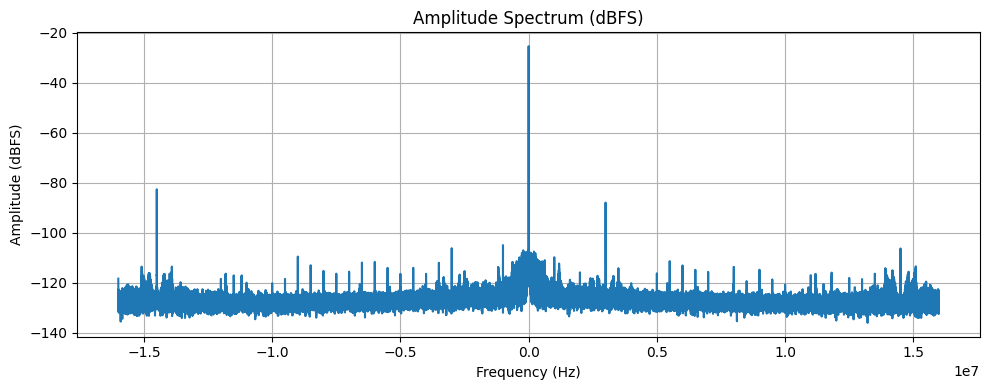

P at DC: 52228623757475.1
sqrt(P): 7226937.370523914
A_dBFS at DC: -25.37711183678894


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# System Parameters
# -----------------------------
Fs = 32e6               # Sampling frequency
N = 65536               # FFT size
N_bits = 12             # ADC resolution
FS = 2**(N_bits - 1)    # Full-scale amplitude (8192)

# -----------------------------
# Load FFT power data
# -----------------------------
# P[k] = averaged |X[k]|^2
P = np.loadtxt("data/fft_spectrum_data.txt")

# -----------------------------
# Recover FFT magnitude
# -----------------------------
# |X[k]| = sqrt(P[k])
X_mag = np.sqrt(P)

# -----------------------------
# Recover real tone amplitude
# -----------------------------
# Since FFT is unscaled:
# |X[k0]| = N * A
# A = |X[k0]| / N
A = X_mag / N

# -----------------------------
# Normalize to Full-Scale
# -----------------------------
A_FS = A / FS

# Convert to dBFS
A_dBFS = 20 * np.log10(A_FS + 1e-20)

# -----------------------------
# Frequency Axis
# -----------------------------
# Spectrum is already centered (tone at DC)
freq = np.linspace(-Fs/2, Fs/2, N)

# -----------------------------
# Plot Amplitude Spectrum
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(freq, A_dBFS)
plt.title("Amplitude Spectrum (dBFS)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Amplitude (dBFS)")
plt.grid(True)
plt.tight_layout()
plt.show()
print("P at DC:", P[N//2])
print("sqrt(P):", np.sqrt(P[N//2]))
print("A_dBFS at DC:", A_dBFS[N//2])

---

# Notebook Section 4 — PSD Derivation

Now the correct PSD derivation.

---

## (1) True signal power

Since:

$$
\begin{equation}
|X[k]| = N A
\end{equation}
$$

Then:

$$
\begin{equation}
|X[k]|^2 = N^2 A^2
\end{equation}
$$

To recover actual signal power:

$$
\begin{equation}
A^2 = \frac{P[k]}{N^2}
\end{equation}
$$

---

## (2) Convert to Power Spectral Density

Each FFT bin represents:

$$
\begin{equation}
\Delta f = \frac{Fs}{N}
\end{equation}
$$

So PSD is:

$$
\begin{equation}
PSD[k] = \frac{A^2}{\Delta f}
\end{equation}
$$

Combining:

$$
\begin{equation}
PSD[k] = \frac{P[k]}{N^2 \Delta f}
\end{equation}
$$

---

## (3) Convert to dBFS/Hz

Normalize power to $\text{FS}^2$:

$$
\begin{equation}
PSD_{FS} = \frac{PSD}{FS^2}
\end{equation}
$$

Then:

$$
\begin{equation}
10\log_{10}(PSD_{FS})
\end{equation}
$$

---

# Notebook Section 5 — PSD Code

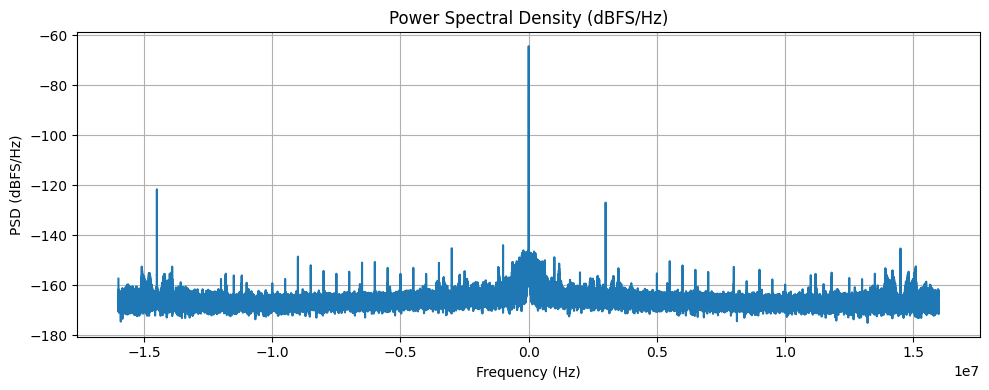

In [6]:
# -----------------------------
# Frequency resolution
# -----------------------------
df = Fs / N

# -----------------------------
# True power per bin
# -----------------------------
# A^2 = P / N^2
# PSD = A^2 / df
PSD = P / (N**2 * df)

# Normalize to FS power
PSD_FS = PSD / (FS**2)

PSD_dBFS_per_Hz = 10 * np.log10(PSD_FS + 1e-20)

# -----------------------------
# Plot PSD
# -----------------------------
plt.figure(figsize=(10,4))
plt.plot(freq, PSD_dBFS_per_Hz)
plt.title("Power Spectral Density (dBFS/Hz)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("PSD (dBFS/Hz)")
plt.grid(True)
plt.tight_layout()
plt.show()

---

# Final Summary

---

### Why divide by N?

Because the FFT is unscaled:

$$
\begin{equation}
X[k] = \sum x[n]
\end{equation}
$$

So coherent tones grow proportionally to $N$.

---

### Why divide by $N^2$ in PSD?

Because:

$$
\begin{equation}
|X|^2 = N^2 A^2
\end{equation}
$$

We must remove FFT gain before computing physical power.

---

### Why $20\log_{10}$ for amplitude and $10\log_{10}$ for PSD?

Because:

* Amplitude is proportional to voltage $\rightarrow 20\log_{10}$
* PSD is power $\rightarrow 10\log_{10}$

---

# What this notebook now guarantees

* Correct amplitude recovery
* Correct dBFS normalization
* Correct PSD scaling
* Physically interpretable results
* Direct comparison against expected $-6.02\,\text{dBFS}$ tone

---

# Extras

---

### (1) From LSB to Voltage (V)

Suppose your ADC has:

* Resolution: (N) bits
* Reference voltage range: (V_\text{ref}) volts

Then each LSB represents:

$$
\begin{equation}
V_\text{LSB} = \frac{V_\text{ref}}{2^N}
\end{equation}
$$

If your ADC is **signed**, the voltage corresponding to a digital code is:

$$
\begin{equation}
V = \text{LSB} \times V_\text{LSB}
\end{equation}
$$

where **LSB** can be positive or negative.

**Example:**

* 12-bit ADC, $\pm\,1\,\text{V}$ range $\rightarrow (2^{12} = 4096)$ levels
* $(V_\text{LSB} = \frac{2,\text{V}}{4096} \approx 0.000488,\text{V})$
* If the ADC code is $1000 \rightarrow (V = 1000 \times 0.000488 \approx 0.488,\text{V})$

---

### (2) From Peak Voltage to RMS Voltage

If your signal is sinusoidal, convert **peak voltage to RMS** as:

$$
\begin{equation}
V_\text{RMS} = \frac{V_\text{peak}}{\sqrt{2}}
\end{equation}
$$

If your ADC measures a centered waveform, you can also compute RMS directly from the digital samples:

$$
\begin{equation}
V_\text{RMS} = \sqrt{\langle V^2 \rangle}
\end{equation}
$$

This is especially useful for complex or modulated signals.

---

### (3) From RMS Voltage to Power in dBm

If the signal is delivered to a known load (R) (commonly $50\,\Omega$ in RF), the power in **watts** is:

$$
\begin{equation}
P = \frac{V_\text{RMS}^2}{R}
\end{equation}
$$

Then convert to **dBm**:

$$
\begin{equation}
P_\text{dBm} = 10 \cdot \log_{10}\left(\frac{P}{1\,\text{mW}}\right)
\end{equation}
$$

**Example:**

* $(V_\text{RMS} = 0.1\,\text{V})$
* $(R = 50\,\Omega)$

$$
\begin{equation}
P = \frac{0.1^2}{50} = 0.0002,\text{W} = 0.2\,\text{mW}
\end{equation}
$$

$$
\begin{equation}
P_\text{dBm} = 10 \cdot \log_{10}(0.2) \approx -7\,\text{dBm}
\end{equation}
$$

---



**Optional:** You can also create a **direct formula from ADC code $rightarrow$ dBm** to simplify calculations.

---

### Direct Conversion: LSB → dBm

Given:

* `adc_code` $\rightarrow$ your ADC digital value
* `N` $\rightarrow$ ADC resolution in bits
* `Vref` $\rightarrow$ ADC voltage reference (peak-to-peak) in volts
* `R` $\rightarrow$ load resistance (usually $50\,\Omega$)

The formula is:

$$
\begin{equation}
P_\text{dBm} = 10 \cdot \log_{10} \left( \frac{( \text{adc\_code} \cdot V_\text{LSB} / \sqrt{2} )^2}{R \cdot 1\,\text{mW}} \right)
\end{equation}
$$

Where:

$$
\begin{equation}
V_\text{LSB} = \frac{V_\text{ref}}{2^N}
\end{equation}
$$

---

### Python Implementation

In [1]:
import numpy as np

def lsb_to_dBm(adc_code, N=12, Vref=2.0, R=50):
    """
    Convert ADC code to power in dBm.
    
    Parameters:
        adc_code : int or np.array
            ADC digital value (can be signed or unsigned)
        N        : int
            ADC resolution in bits
        Vref     : float
            Peak-to-peak voltage of ADC reference (V)
        R        : float
            Load resistance (Ohms)
    
    Returns:
        float or np.array : Power in dBm
    """
    V_LSB = Vref / (2**N)
    V_rms = (adc_code * V_LSB) / np.sqrt(2)  # convert to RMS assuming sinusoid
    P_watt = V_rms**2 / R
    P_dBm = 10 * np.log10(P_watt / 1e-3)
    return P_dBm

In [2]:
# Example usage:
adc_value = 1000
power_dBm = lsb_to_dBm(adc_value, N=12, Vref=2.0, R=50)
print(f"ADC value {adc_value} corresponds to {power_dBm:.2f} dBm")

ADC value 1000 corresponds to 3.77 dBm


---

This function handles **single values or arrays of ADC samples**. You can directly feed your ADC readings from a measurement and get the corresponding RF power in dBm.

---

### Python Implementation: Signed ADC (0-centered) $\rightarrow$ dBm

In [3]:
import numpy as np

def signed_adc_to_dBm(adc_code, N=12, Vref=2.0, R=50):
    """
    Convert a signed ADC code (centered at 0) to power in dBm.

    Parameters:
        adc_code : int or np.array
            ADC digital value (signed, from -2^(N-1) to 2^(N-1)-1)
        N        : int
            ADC resolution in bits
        Vref     : float
            Full-scale voltage (peak-to-peak) of ADC reference (V)
        R        : float
            Load resistance in Ohms (default 50 Ω)

    Returns:
        float or np.array : Power in dBm
    """
    # Convert ADC code to voltage (centered at 0)
    V_LSB = Vref / (2**N)
    V = adc_code * V_LSB

    # Convert to RMS voltage (assuming sinusoidal signal)
    V_rms = V / np.sqrt(2)

    # Compute power in watts
    P_watt = V_rms**2 / R

    # Convert to dBm
    P_dBm = 10 * np.log10(P_watt / 1e-3)
    return P_dBm

In [4]:
# Example usage:
adc_value = 1000        # signed ADC code
power_dBm = signed_adc_to_dBm(adc_value, N=12, Vref=2.0, R=50)
print(f"ADC value {adc_value} corresponds to {power_dBm:.2f} dBm")

ADC value 1000 corresponds to 3.77 dBm


---

**Features of this version:**

* Automatically handles signed ADCs centered at 0
* Can take **arrays of ADC samples**
* Converts directly to **dBm** for an RF load ($50\,\Omega$ typical)
* Assumes **sinusoidal signals**, RMS conversion included

---